In [2]:
#PART-A

In [3]:
#INSTALL DEPENDENCIES
!pip install nibabel kaggle tensorflow

In [4]:
#IMPORT LIBRARIES
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import cv2
import tensorflow as tf

from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from google.colab import files

In [5]:
# Verify library versions and check for installation errors
try:
    print(f"TensorFlow version: {tf.__version__}")
    print(f"Numpy version: {np.__version__}")
    print(f"Nibabel version: {nib.__version__}")
    # Test a small Keras component to ensure it's functional
    test_layer = layers.Dense(10)
    print("Keras layers are accessible.")
except Exception as e:
    print(f"An error occurred during verification: {e}")

TensorFlow version: 2.19.0
Numpy version: 2.0.2
Nibabel version: 5.4.2
Keras layers are accessible.


In [6]:
#UPLOAD KAGGLE JSON FILE
files.upload()  # Upload kaggle.json here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"laasyasharma","key":"397b195bea64439fa01213c4f77289d9"}'}

In [7]:
#SETUP KAGGLE API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
import os

# Download only if not already downloaded
if not os.path.exists("brats20-dataset-training-validation.zip"):
    !kaggle datasets download -d awsaf49/brats20-dataset-training-validation

# Extract only if folder not already present
if not os.path.exists("BraTS2020_TrainingData"):
    !unzip -oq brats20-dataset-training-validation.zip

Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats20-dataset-training-validation
License(s): CC0-1.0
100% 4.16G/4.16G [04:54<00:00, 15.2MB/s]



In [9]:
#LOAD MRI + MASK FUNCTION
IMG_SIZE = 128

def load_mri_mask(mri_path, mask_path, num_slices=5):
    img = nib.load(mri_path).get_fdata()
    mask = nib.load(mask_path).get_fdata()

    images = []
    masks = []

    total_slices = img.shape[2]
    center = total_slices // 2

    start = center - num_slices // 2
    end = center + num_slices // 2

    for i in range(start, end):
        if i >= 0 and i < total_slices:
            img_slice = img[:, :, i]
            mask_slice = mask[:, :, i]

            img_slice = cv2.resize(img_slice, (IMG_SIZE, IMG_SIZE))
            mask_slice = cv2.resize(mask_slice, (IMG_SIZE, IMG_SIZE))

            mean = np.mean(img_slice)
            std = np.std(img_slice)
            if std != 0:
                img_slice = (img_slice - mean) / std
            mask_slice = (mask_slice > 0).astype(np.float32)

            images.append(img_slice)
            masks.append(mask_slice)

    return images, masks

In [10]:
#BUILD DATASET
images = []
masks = []

total_files = 0
valid_files = 0
corrupted_files = 0
missing_masks = 0

for root, dirs, files_ in os.walk("."):
    for file in files_:
        if "_flair.nii" in file:
            total_files += 1

            mri_path = os.path.join(root, file)
            mask_path = mri_path.replace("_flair.nii", "_seg.nii")

            if os.path.exists(mask_path):
                try:
                    img_slices, mask_slices = load_mri_mask(mri_path, mask_path)
                    images.extend(img_slices)
                    masks.extend(mask_slices)
                    valid_files += 1
                except Exception as e:
                    print(f"Skipping corrupted file: {mri_path}")
                    corrupted_files += 1
            else:
                missing_masks += 1

images = np.array(images)
masks = np.array(masks)

images = images[..., np.newaxis]
masks = masks[..., np.newaxis]

print("\n===== DATASET SUMMARY =====")
print("Total MRI files found:", total_files)
print("Valid files used:", valid_files)
print("Corrupted files skipped:", corrupted_files)
print("Missing mask files:", missing_masks)
print("Total Samples (after slicing):", len(images))
print("Images shape:", images.shape)
print("Masks shape:", masks.shape)


===== DATASET SUMMARY =====
Total MRI files found: 494
Valid files used: 368
Corrupted files skipped: 0
Missing mask files: 126
Total Samples (after slicing): 1472
Images shape: (1472, 128, 128, 1)
Masks shape: (1472, 128, 128, 1)


In [11]:
#TRAIN TEST SPLIT
X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

In [12]:
#DICE LOSS + DICE COEFFICIENT
def dice_coefficient(y_true, y_pred):
    smooth = 1e-6
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

In [13]:
#ATTENTION BLOCK
def attention_block(x, g, filters):
    theta = layers.Conv2D(filters, 1, padding="same")(x)
    phi = layers.Conv2D(filters, 1, padding="same")(g)
    add = layers.Add()([theta, phi])
    act = layers.Activation("relu")(add)
    psi = layers.Conv2D(1, 1, activation="sigmoid")(act)
    return layers.Multiply()([x, psi])

In [14]:
#CONV BLOCK
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    return x

In [15]:
#BUILD ATTENTION U-NET
def build_attention_unet(input_shape=(IMG_SIZE, IMG_SIZE, 1)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = conv_block(inputs, 64)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 128)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 256)
    p3 = layers.MaxPooling2D()(c3)

    c4 = conv_block(p3, 512)

    # Decoder
    u3 = layers.UpSampling2D()(c4)
    att3 = attention_block(c3, u3, 256)
    u3 = layers.Concatenate()([u3, att3])
    c5 = conv_block(u3, 256)

    u2 = layers.UpSampling2D()(c5)
    att2 = attention_block(c2, u2, 128)
    u2 = layers.Concatenate()([u2, att2])
    c6 = conv_block(u2, 128)

    u1 = layers.UpSampling2D()(c6)
    att1 = attention_block(c1, u1, 64)
    u1 = layers.Concatenate()([u1, att1])
    c7 = conv_block(u1, 64)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c7)

    return Model(inputs, outputs)

model_seg = build_attention_unet()
model_seg.compile(optimizer="adam", loss=dice_loss,
                  metrics=[dice_coefficient, "accuracy"])

model_seg.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_2[

 Total params: 8,052,420 (30.72 MB)

 Trainable params: 8,046,788 (30.70 MB)

 Non-trainable params: 5,632 (22.00 KB)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True
)

In [17]:
history = model_seg.fit(
    X_train_img, y_train_img,
    validation_data=(X_test_img, y_test_img),
    epochs=30,
    batch_size=4,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.9106 - dice_coefficient: 0.4292 - loss: 0.5709

295/295 ━━━━━━━━━━━━━━━━━━━━ 87s 170ms/step - accuracy: 0.9589 - dice_coefficient: 0.5903 - loss: 0.4104 - val_accuracy: 0.9832 - val_dice_coefficient: 0.6401 - val_loss: 0.3598
Epoch 2/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - accuracy: 0.9864 - dice_coefficient: 0.7734 - loss: 0.2265 - val_accuracy: 0.6375 - val_dice_coefficient: 0.1331 - val_loss: 0.8668
Epoch 3/30
294/295 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9873 - dice_coefficient: 0.7818 - loss: 0.2182

295/295 ━━━━━━━━━━━━━━━━━━━━ 22s 76ms/step - accuracy: 0.9876 - dice_coefficient: 0.7889 - loss: 0.2111 - val_accuracy: 0.9810 - val_dice_coefficient: 0.7420 - val_loss: 0.2577
Epoch 4/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 0.9880 - dice_coefficient: 0.7981 - loss: 0.2023 - val_accuracy: 0.9792 - val_dice_coefficient: 0.4622 - val_loss: 0.5385
Epoch 5/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 22s 74ms/step - accuracy: 0.9886 - dice_coefficient: 0.8059 - loss: 0.1940 - val_accuracy: 0.9276 - val_dice_coefficient: 0.4563 - val_loss: 0.5433
Epoch 6/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 22s 74ms/step - accuracy: 0.9882 - dice_coefficient: 0.7931 - loss: 0.2048 - val_accuracy: 0.9818 - val_dice_coefficient: 0.5694 - val_loss: 0.4308
Epoch 7/30
294/295 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9890 - dice_coefficient: 0.8022 - loss: 0.1978

295/295 ━━━━━━━━━━━━━━━━━━━━ 22s 76ms/step - accuracy: 0.9889 - dice_coefficient: 0.8093 - loss: 0.1909 - val_accuracy: 0.9900 - val_dice_coefficient: 0.8260 - val_loss: 0.1740
Epoch 8/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 0.9892 - dice_coefficient: 0.8102 - loss: 0.1896 - val_accuracy: 0.9894 - val_dice_coefficient: 0.7936 - val_loss: 0.2063
Epoch 9/30
294/295 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9890 - dice_coefficient: 0.8114 - loss: 0.1886

295/295 ━━━━━━━━━━━━━━━━━━━━ 22s 76ms/step - accuracy: 0.9892 - dice_coefficient: 0.8097 - loss: 0.1906 - val_accuracy: 0.9902 - val_dice_coefficient: 0.8300 - val_loss: 0.1699
Epoch 10/30
294/295 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9901 - dice_coefficient: 0.8226 - loss: 0.1774

295/295 ━━━━━━━━━━━━━━━━━━━━ 22s 76ms/step - accuracy: 0.9898 - dice_coefficient: 0.8233 - loss: 0.1770 - val_accuracy: 0.9908 - val_dice_coefficient: 0.8430 - val_loss: 0.1570
Epoch 11/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 0.9901 - dice_coefficient: 0.8313 - loss: 0.1679 - val_accuracy: 0.9857 - val_dice_coefficient: 0.7881 - val_loss: 0.2117
Epoch 12/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 0.9896 - dice_coefficient: 0.8225 - loss: 0.1773 - val_accuracy: 0.9787 - val_dice_coefficient: 0.5161 - val_loss: 0.4845
Epoch 13/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 0.9900 - dice_coefficient: 0.8300 - loss: 0.1701 - val_accuracy: 0.9907 - val_dice_coefficient: 0.8287 - val_loss: 0.1709
Epoch 14/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 0.9905 - dice_coefficient: 0.8340 - loss: 0.1662 - val_accuracy: 0.9902 - val_dice_coefficient: 0.8121 - val_loss: 0.1875
Epoch 15/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 

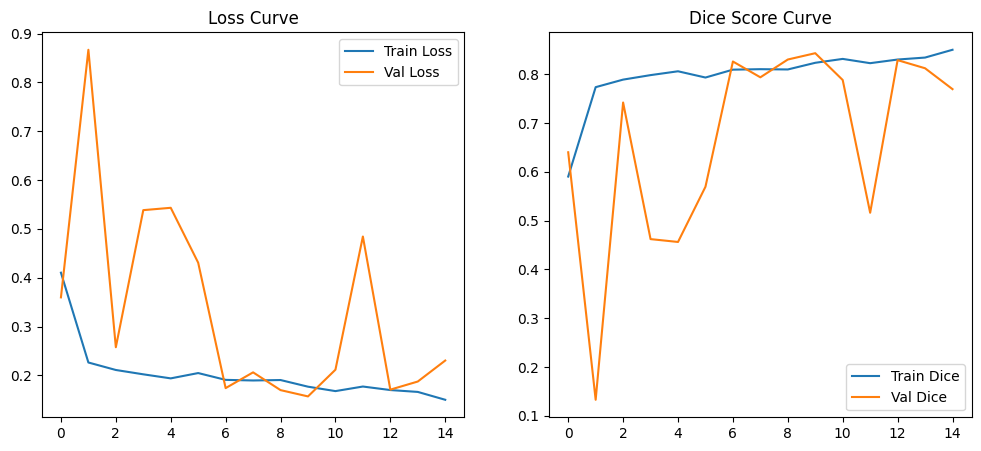

In [18]:
#training curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(history.history["dice_coefficient"], label="Train Dice")
plt.plot(history.history["val_dice_coefficient"], label="Val Dice")
plt.legend()
plt.title("Dice Score Curve")

plt.show()

In [19]:
#evaluate dice score
preds = model_seg.predict(X_test_img)
preds_binary = (preds > 0.5).astype(np.float32)

dice_scores = []

for i in range(len(preds_binary)):
    dice = dice_coefficient(
        tf.convert_to_tensor(y_test_img[i]),
        tf.convert_to_tensor(preds_binary[i])
    ).numpy()
    dice_scores.append(dice)

print("Average Dice Score:", np.mean(dice_scores))

10/10 ━━━━━━━━━━━━━━━━━━━━ 23s 945ms/step
Average Dice Score: 0.7405213


In [20]:
# IoU Score Calculation

iou_scores = []

for i in range(len(preds_binary)):
    intersection = np.logical_and(y_test_img[i], preds_binary[i])
    union = np.logical_or(y_test_img[i], preds_binary[i])

    iou = np.sum(intersection) / np.sum(union) if np.sum(union) != 0 else 0
    iou_scores.append(iou)

print("Average IoU Score:", np.mean(iou_scores))

Average IoU Score: 0.5955026657151186


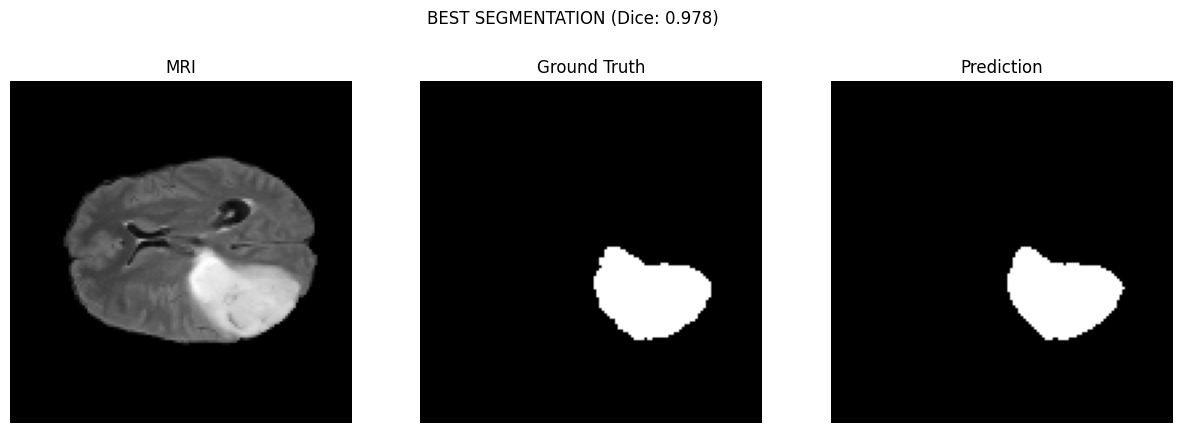

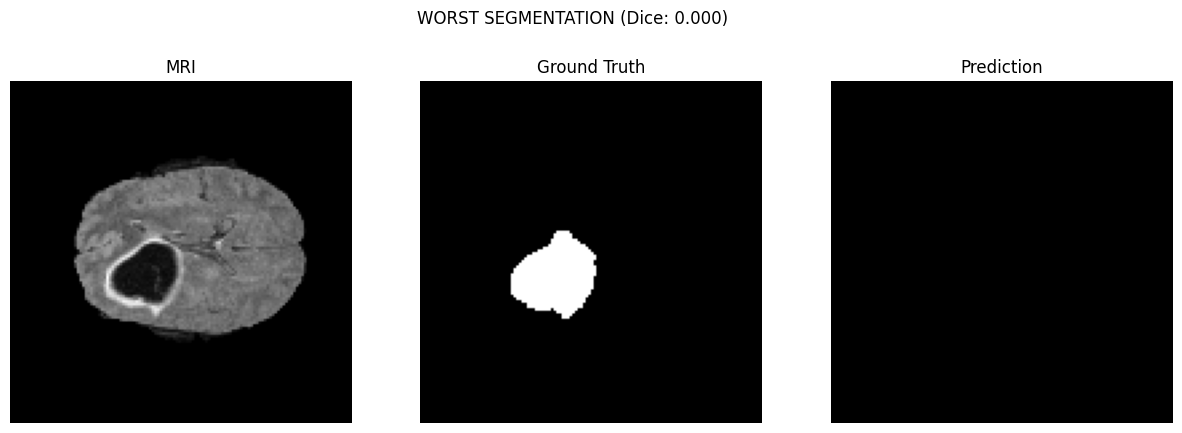

In [102]:
dice_array = np.array(dice_scores)

# Filter only images where tumor exists
non_empty_indices = [i for i in range(len(y_test_img)) if np.sum(y_test_img[i]) > 0]

filtered_dice = dice_array[non_empty_indices]

best_idx = non_empty_indices[np.argmax(filtered_dice)]
worst_idx = non_empty_indices[np.argmin(filtered_dice)]

for idx, label in zip([best_idx, worst_idx], ["BEST", "WORST"]):
    plt.figure(figsize=(15,5))

    plt.suptitle(f"{label} SEGMENTATION (Dice: {dice_array[idx]:.3f})")

    # MRI
    plt.subplot(1,3,1)
    plt.imshow(X_test_img[idx].squeeze(), cmap="gray")
    plt.title("MRI")
    plt.axis('off')

    # Ground Truth
    plt.subplot(1,3,2)
    plt.imshow(y_test_img[idx].squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis('off')

    # Prediction
    plt.subplot(1,3,3)
    plt.imshow(preds_binary[idx].squeeze(), cmap="gray")
    plt.title("Prediction")
    plt.axis('off')

    plt.show()

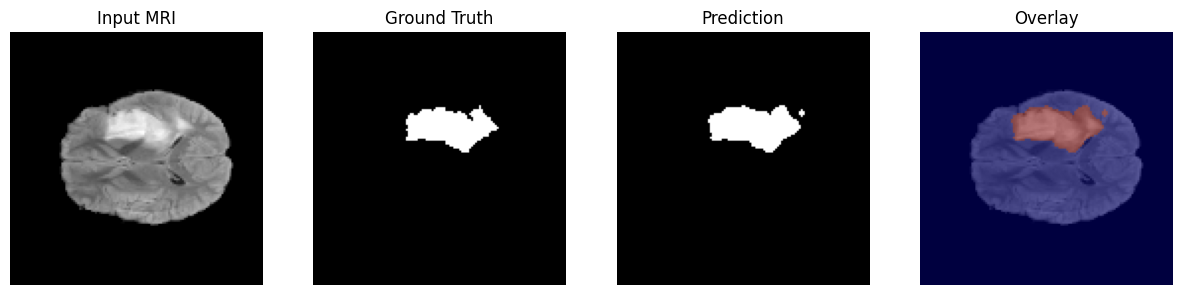

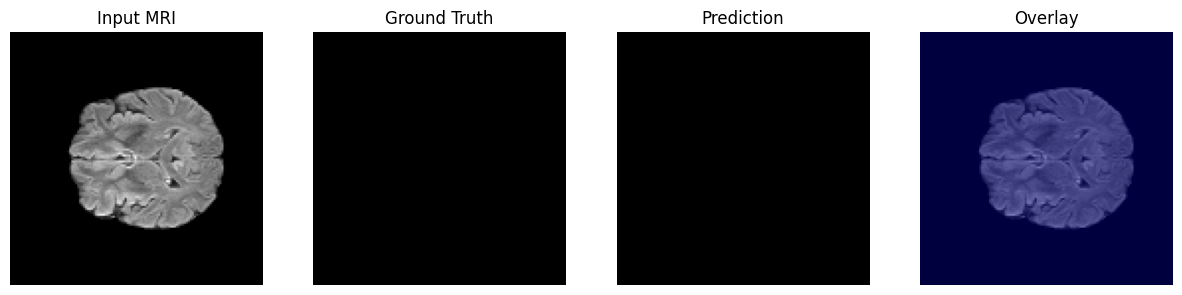

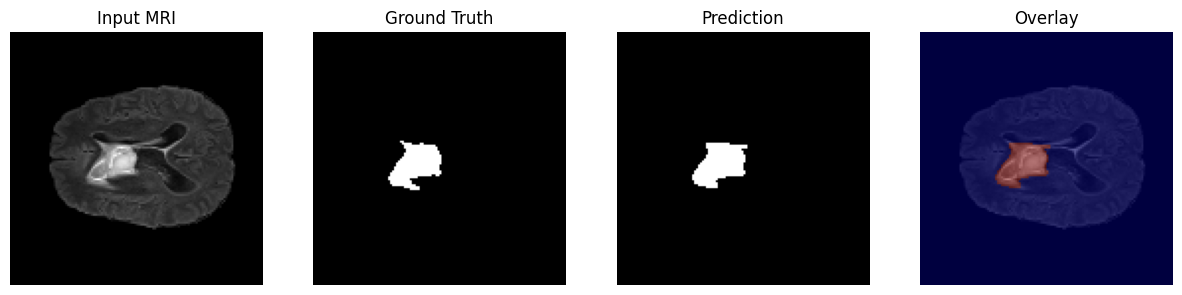

In [21]:
#visualize segmentation
num_samples = 3  # show multiple images

for i in range(num_samples):
    plt.figure(figsize=(15,5))

    # MRI
    plt.subplot(1,4,1)
    plt.imshow(X_test_img[i].squeeze(), cmap="gray")
    plt.title("Input MRI")
    plt.axis('off')

    # Ground Truth
    plt.subplot(1,4,2)
    plt.imshow(y_test_img[i].squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis('off')

    # Prediction
    plt.subplot(1,4,3)
    plt.imshow(preds_binary[i].squeeze(), cmap="gray")
    plt.title("Prediction")
    plt.axis('off')

    # Overlay
    plt.subplot(1,4,4)
    plt.imshow(X_test_img[i].squeeze(), cmap="gray")
    plt.imshow(preds_binary[i].squeeze(), alpha=0.5, cmap='jet')
    plt.title("Overlay")
    plt.axis('off')

    plt.show()

In [22]:
model_seg.save("attention_unet_final.h5")

In [23]:
#PART-B

In [24]:
#INSTALL
!pip install imbalanced-learn shap

In [25]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from imblearn.over_sampling import SMOTE

In [26]:
#LOAD STROKE DATASET
from google.colab import files
files.upload()   # Upload healthcare-dataset-stroke-data.csv

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"laasyasharma","key":"397b195bea64439fa01213c4f77289d9"}'}

In [27]:
!kaggle datasets download -d fedesoriano/stroke-prediction-dataset
!unzip -o stroke-prediction-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset
License(s): copyright-authors
100% 67.4k/67.4k [00:00<00:00, 276kB/s]

Archive:  stroke-prediction-dataset.zip
  inflating: healthcare-dataset-stroke-data.csv  


In [28]:
clinical_df = pd.read_csv("healthcare-dataset-stroke-data.csv")

clinical_df = clinical_df.dropna()

if "id" in clinical_df.columns:
    clinical_df = clinical_df.drop(["id"], axis=1)

clinical_df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [29]:
#PREPROCESSING
X = clinical_df.drop("stroke", axis=1)
y = clinical_df["stroke"]

X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)

In [30]:
#TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
#SMOTE BALANCING
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

X_train_sm = pd.DataFrame(X_train_sm, columns=X_train.columns)


In [77]:
# =========================
# MULTIPLE MODEL TRAINING & EVALUATION
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score

# =========================
# Scaling (for SVM & Logistic Regression)
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

results = {}
models_outputs = {}

# =========================
# Logistic Regression
# =========================
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train_sm)
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:,1]

print("\nLogistic Regression Report:")
print(classification_report(y_test, lr_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, lr_pred))
recall = recall_score(y_test, lr_pred)
print("Recall (Stroke Class):", recall)
results["Logistic Regression"] = roc_auc_score(y_test, lr_prob)
models_outputs["Logistic Regression"] = lr_prob


# =========================
# SVM
# =========================
svm = SVC(probability=True, class_weight='balanced')
svm.fit(X_train_scaled, y_train_sm)
svm_pred = svm.predict(X_test_scaled)
svm_prob = svm.predict_proba(X_test_scaled)[:,1]

print("\nSVM Report:")
print(classification_report(y_test, svm_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, svm_pred))
recall = recall_score(y_test, svm_pred)
print("Recall (Stroke Class):", recall)
results["SVM"] = roc_auc_score(y_test, svm_prob)
models_outputs["SVM"] = svm_prob


# =========================
# Random Forest
# =========================
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train_sm, y_train_sm)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print("\nRandom Forest Report:")
print(classification_report(y_test, rf_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
recall = recall_score(y_test, rf_pred)
print("Recall (Stroke Class):", recall)
results["Random Forest"] = roc_auc_score(y_test, rf_prob)
models_outputs["Random Forest"] = rf_prob


# =========================
# XGBoost
# =========================
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)
xgb.fit(X_train_sm, y_train_sm)
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

print("\nXGBoost Report:")
print(classification_report(y_test, xgb_pred))
print("\nXGBoost Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))
recall = recall_score(y_test, xgb_pred)
print("Recall (Stroke Class):", recall)
results["XGBoost"] = roc_auc_score(y_test, xgb_prob)
models_outputs["XGBoost"] = xgb_prob


# =========================
# Compare Models
# =========================
results_df = pd.DataFrame(results.items(), columns=["Model", "ROC-AUC"])
print("\nModel Comparison:")
results_df = results_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

print("\nFinal Model Ranking:")
print(results_df)
results_df.to_csv("model_comparison.csv", index=False)

# =========================
# Select Best Model
# =========================
best_model = results_df.sort_values(by="ROC-AUC", ascending=False).iloc[0]["Model"]
print(f"\nFinal Selected Model for Stroke Prediction: {best_model}")

stroke_risk_aligned = models_outputs[best_model]
y_prob = stroke_risk_aligned


Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.98      0.75      0.85       929
           1       0.15      0.79      0.26        53

    accuracy                           0.76       982
   macro avg       0.57      0.77      0.56       982
weighted avg       0.94      0.76      0.82       982

Confusion Matrix:
[[700 229]
 [ 11  42]]
Recall (Stroke Class): 0.7924528301886793

SVM Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       929
           1       0.17      0.17      0.17        53

    accuracy                           0.91       982
   macro avg       0.56      0.56      0.56       982
weighted avg       0.91      0.91      0.91       982

Confusion Matrix:
[[884  45]
 [ 44   9]]
Recall (Stroke Class): 0.16981132075471697

Random Forest Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       929
     

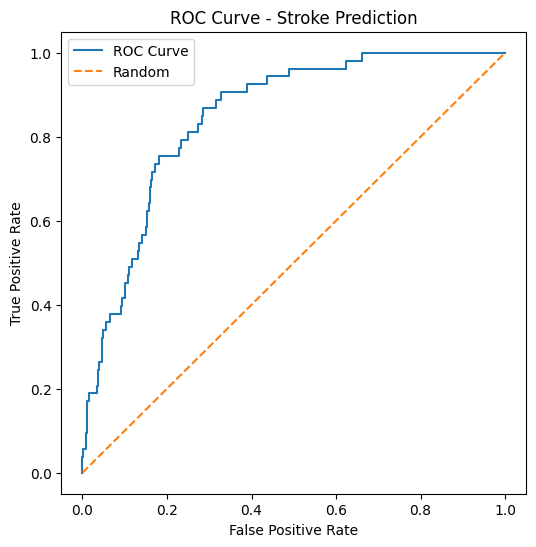

In [103]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, models_outputs[best_model])

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Stroke Prediction")
plt.legend()
plt.show()

In [78]:
%matplotlib inline
plt.rcParams['figure.figsize'] = (20,12)
plt.rcParams['figure.dpi'] = 100

In [79]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

# Handle different SHAP output formats
if isinstance(shap_values, list):
    shap_values_correct = shap_values[1]  # old version
else:
    # new version: shape (samples, features, classes)
    shap_values_correct = shap_values[:, :, 1]

print("Final SHAP shape:", shap_values_correct.shape)

Final SHAP shape: (982, 16)


In [80]:
def get_top_features(index, top_n=3):

    shap_val = shap_values_correct[index]

    feature_importance = pd.Series(
        shap_val,
        index=X_test.columns
    )

    top_features = feature_importance.abs().sort_values(
        ascending=False
    ).head(top_n)

    return top_features

In [81]:
#NEURO-SYMBOLIC RULE ENGINE

In [82]:
#SYMBOLIC RISK BOOST RULES
def symbolic_risk_boost(row, base_risk):
    boost = 0

    if row.get("hypertension", 0) == 1:
        boost += 0.05

    if row.get("heart_disease", 0) == 1:
        boost += 0.05

    if row.get("avg_glucose_level", 0) > 180:
        boost += 0.05

    if row.get("bmi", 0) > 35:
        boost += 0.05

    return min(base_risk + boost, 1.0)

In [83]:
#ADVANCED RISK STRATIFICATION
def risk_category(score):
    if score < 0.25:
        return "LOW"
    elif score < 0.5:
        return "MODERATE"
    elif score < 0.75:
        return "HIGH"
    else:
        return "CRITICAL"

In [84]:
#NATURAL LANGUAGE REPORT GENERATOR
def generate_clinical_report(index):

    base_risk = y_prob[index]
    boosted_risk = symbolic_risk_boost(X_test.iloc[index], base_risk)
    category = risk_category(boosted_risk)

    top_features = get_top_features(index)

    explanation_text = ""
    for feature, value in top_features.items():
        explanation_text += f"- {feature} significantly influenced risk.\n"

    report = f"""
    -------- Stroke Risk Assessment Report --------

    Base ML Risk Score: {base_risk:.3f}
    Risk After Symbolic Adjustment: {boosted_risk:.3f}
    Risk Category: {category}

    Key Contributing Clinical Factors:
    {explanation_text}

    Clinical Recommendation:
    {'Immediate neurological evaluation recommended.' if category in ['HIGH','CRITICAL'] else 'Lifestyle and monitoring advised.'}

    ------------------------------------------------
    """

    return report

In [85]:
#GENERATE SAMPLE REPORT
print(generate_clinical_report(6))


    -------- Stroke Risk Assessment Report --------

    Base ML Risk Score: 0.023
    Risk After Symbolic Adjustment: 0.023
    Risk Category: LOW

    Key Contributing Clinical Factors:
    - age significantly influenced risk.
- ever_married_Yes significantly influenced risk.
- hypertension significantly influenced risk.


    Clinical Recommendation:
    Lifestyle and monitoring advised.

    ------------------------------------------------
    


In [86]:
#SAVE STROKE MODEL
joblib.dump(rf, "stroke_rf_model.pkl")

['stroke_rf_model.pkl']

In [87]:
#PART C

In [88]:
#LOAD SEGMENTATION MODEL (IF RUNTIME RESTARTED)
# from tensorflow.keras.models import load_model

# model_seg = load_model(
#     "attention_unet_final.h5",
#     custom_objects={
#         "dice_loss": dice_loss,
#         "dice_coefficient": dice_coefficient
#     }
# )

In [89]:
#COMPUTE TUMOR SEVERITY SCORE
def compute_tumor_severity(mri_image):

    pred = model_seg.predict(np.expand_dims(mri_image, axis=0))
    pred_binary = (pred > 0.5).astype(np.float32)

    tumor_pixels = np.sum(pred_binary)
    total_pixels = pred_binary.size

    severity_score = tumor_pixels / total_pixels

    return float(severity_score)

In [90]:
#CALCULATE SEVERITY FOR TEST MRI SET
tumor_severity_scores = []

for i in range(len(X_test_img)):
    severity = compute_tumor_severity(X_test_img[i])
    tumor_severity_scores.append(severity)

tumor_severity_scores = np.array(tumor_severity_scores)

print("Sample Tumor Severity Scores:")
print(tumor_severity_scores[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━

In [91]:
#ALGIN SAMPLE LENGTHS
min_samples = min(len(y_prob), len(tumor_severity_scores))

stroke_risk_aligned = y_prob[:min_samples]
tumor_severity_aligned = tumor_severity_scores[:min_samples]
X_test_aligned = X_test.iloc[:min_samples].reset_index(drop=True)

In [92]:
#FUSION FUNCTION
def multimodal_fusion(index):

    stroke_base = stroke_risk_aligned[index]
    tumor_score = tumor_severity_aligned[index]

    # Weighted fusion
    w1 = 0.7
    w2 = 0.3

    fused_score = (w1 * stroke_base) + (w2 * tumor_score)

    # Apply symbolic boost again
    fused_score = symbolic_risk_boost(
        X_test_aligned.iloc[index],
        fused_score
    )

    fused_score = min(fused_score, 1.0)

    category = risk_category(fused_score)

    return fused_score, category

In [93]:
#GENERATE FULL MULTIMODAL REPORT
def generate_multimodal_report(index):

    stroke_base = stroke_risk_aligned[index]
    tumor_score = tumor_severity_aligned[index]

    fused_score, category = multimodal_fusion(index)

    top_features = get_top_features(index)

    explanation_text = ""
    for feature in top_features.index:
        explanation_text += f"- {feature} significantly influenced stroke prediction.\n"

    report = f"""
    ================= FINAL MULTIMODAL RISK REPORT =================

    Stroke ML Risk Score: {stroke_base:.3f}
    Tumor Severity Score (MRI): {tumor_score:.3f}

    Final Fused Risk Score: {fused_score:.3f}
    Risk Category: {category}

    Key Clinical Drivers:
    {explanation_text}

    Integrated Interpretation:
    The final risk score combines MRI-based tumor burden
    and structured clinical stroke risk factors using a
    weighted multimodal fusion strategy.

    Recommendation:
    {'Immediate neurological intervention advised.' if category in ['HIGH','CRITICAL'] else 'Regular monitoring and preventive care advised.'}

    ================================================================
    """

    return report

In [94]:
#GENERATE SAMPLE FINAL REPORT
print(generate_multimodal_report(0))


    ================= FINAL MULTIMODAL RISK REPORT =================

    Stroke ML Risk Score: 0.875
    Tumor Severity Score (MRI): 0.045

    Final Fused Risk Score: 0.676
    Risk Category: HIGH

    Key Clinical Drivers:
    - age significantly influenced stroke prediction.
- Residence_type_Urban significantly influenced stroke prediction.
- smoking_status_never smoked significantly influenced stroke prediction.


    Integrated Interpretation:
    The final risk score combines MRI-based tumor burden
    and structured clinical stroke risk factors using a
    weighted multimodal fusion strategy.

    Recommendation:
    Immediate neurological intervention advised.

    


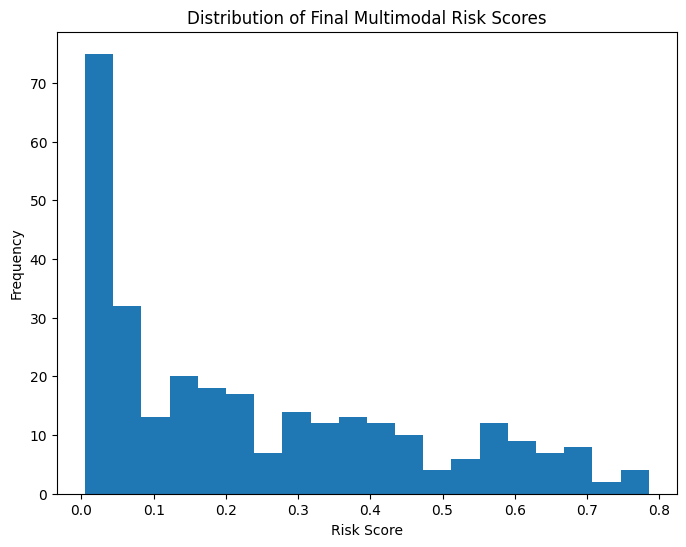

In [95]:
#VISUALIZE FUSION DISTRIBUTION
fused_scores = []

for i in range(min_samples):
    score, _ = multimodal_fusion(i)
    fused_scores.append(score)

plt.figure(figsize=(8,6))
plt.hist(fused_scores, bins=20)
plt.title("Distribution of Final Multimodal Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.show()

In [96]:
#SAVE FINAL FUSION DATA
fusion_df = pd.DataFrame({
    "Stroke_Risk": stroke_risk_aligned,
    "Tumor_Severity": tumor_severity_aligned,
    "Final_Fused_Risk": fused_scores
})

fusion_df.to_csv("final_multimodal_results.csv", index=False)

In [97]:
#upgrades
#1 - TRAINABLE FUSION MODEL
# ------------------------------
# Upgrade 1: Trainable Fusion
# ------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

fusion_features = pd.DataFrame({
    "stroke_risk": stroke_risk_aligned,
    "tumor_severity": tumor_severity_aligned
})

fusion_target = y_test[:len(fusion_features)].reset_index(drop=True)

fusion_model = LogisticRegression()
fusion_model.fit(fusion_features, fusion_target)

fusion_probs = fusion_model.predict_proba(fusion_features)[:,1]

fusion_auc = roc_auc_score(fusion_target, fusion_probs)

print("Trainable Fusion AUC:", fusion_auc)

Trainable Fusion AUC: 0.8006272401433692


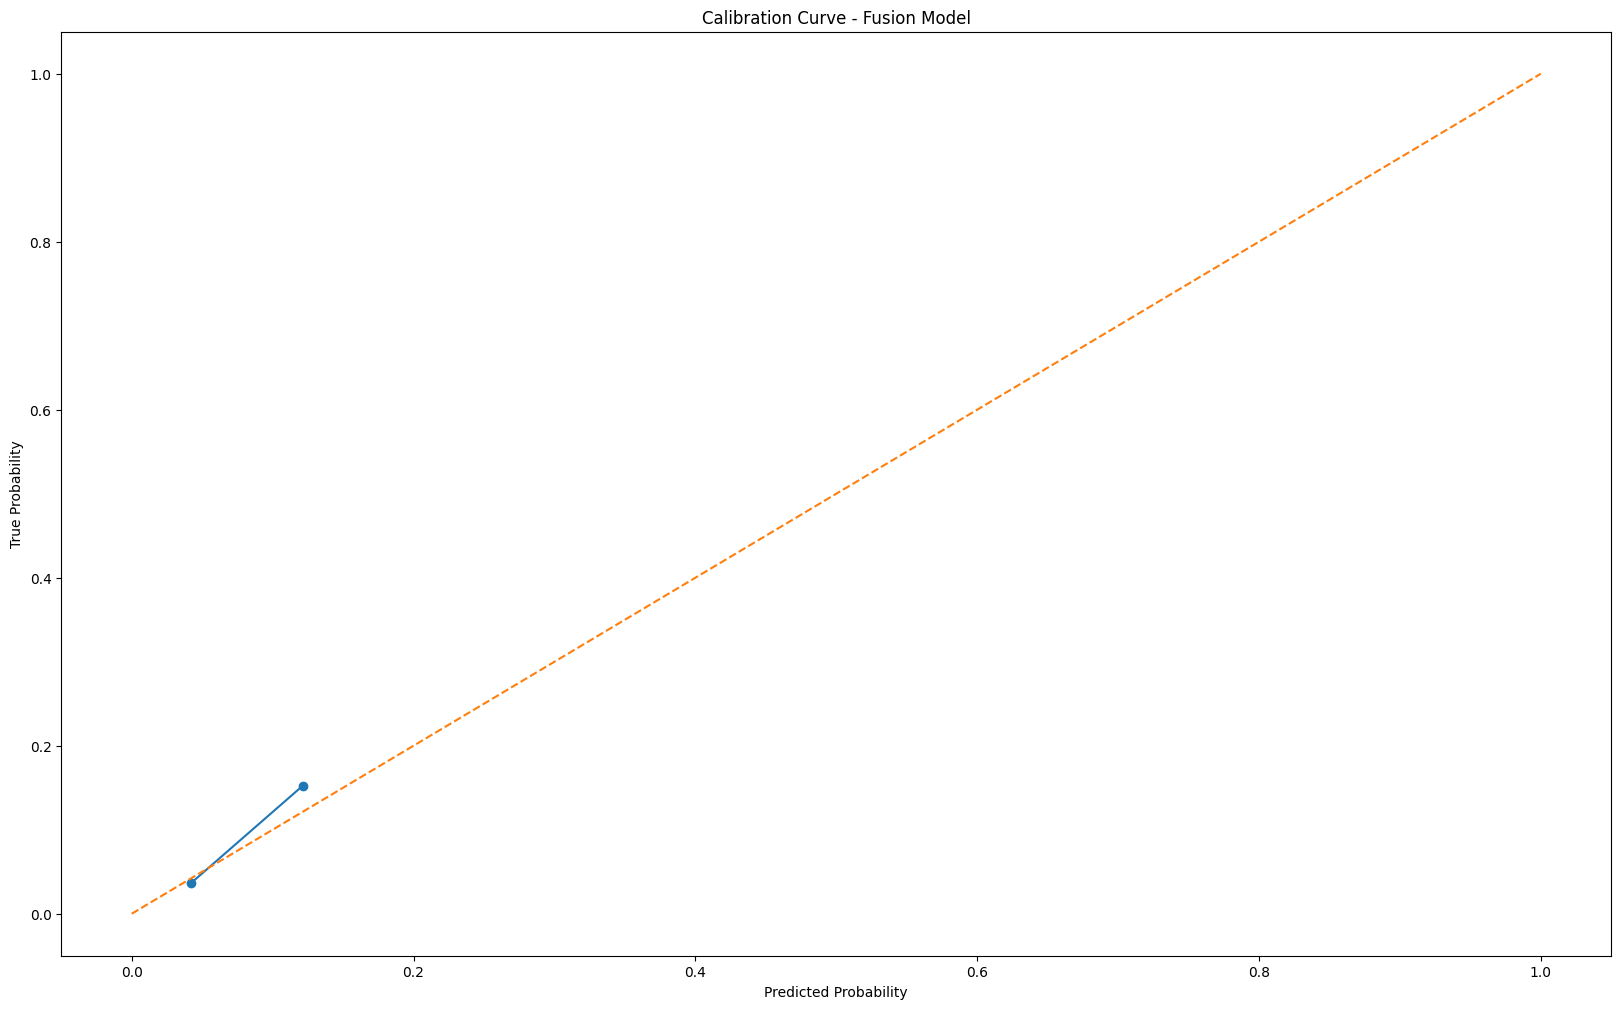

In [98]:
#2 - CALIBRATION ANALYSIS
# ------------------------------
# Upgrade 2: Calibration Curve
# ------------------------------

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    fusion_target,
    fusion_probs,
    n_bins=10
)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve - Fusion Model")
plt.show()

In [99]:
#3 --> 5-FOLD CROSS-VALIDATION (STROKE MODEL ONLY)
# ------------------------------
# Upgrade 3: 5-Fold Cross-Validation
# ------------------------------

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []

for train_index, test_index in kf.split(X, y):

    X_tr, X_te = X.iloc[train_index], X.iloc[test_index]
    y_tr, y_te = y.iloc[train_index], y.iloc[test_index]

    sm = SMOTE(random_state=42)
    X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    )

    model.fit(X_tr_sm, y_tr_sm)

    preds = model.predict_proba(X_te)[:,1]
    auc = roc_auc_score(y_te, preds)

    auc_scores.append(auc)

print("Mean CV AUC:", np.mean(auc_scores))
print("Std CV AUC:", np.std(auc_scores))

Mean CV AUC: 0.7957233054093459
Std CV AUC: 0.01030945482367142
